In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error



In [ ]:
# leer los datos

data = pd.read_csv("train.csv")
data.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [ ]:
data["LotArea"].isnull().sum()
data["LotArea"]

,LotArea
0,8450
1,9600
2,11250
3,9550
4,14260
...,...
1455,7917
1456,13175
1457,9042
1458,9717


In [ ]:
data["SalePrice"].isnull().sum()
data["SalePrice"]

,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000
...,...
1455,175000
1456,210000
1457,266500
1458,142125


<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

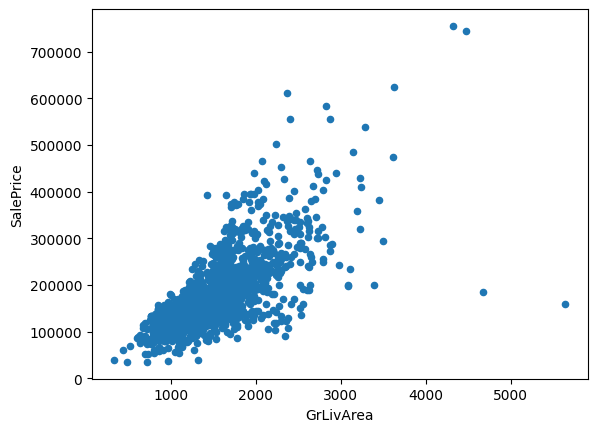

In [ ]:
data.plot.scatter(x = "GrLivArea", y = "SalePrice")

In [ ]:
#redimensionar los datos

x = np.array(data["GrLivArea"]).reshape(-1,1)
y = np.array(data["SalePrice"])


# crear el modelo
modelo = LinearRegression()
modelo.fit(x,y)


# obtener los datos del modelo

m = modelo.coef_
b = modelo.intercept_

# obtener la prediccion
Y_predic = modelo.predict(x)
print(Y_predic)
print(y)


#calcular metricas

r2 = r2_score(y,Y_predic)
rmse = mean_squared_error(y,Y_predic)**(1/2)

print(f"r2 : {r2:.2f}")
print(f"rmse : {rmse:.2f}")





[201761.93968805 153767.53887136 209903.84696945 ... 269254.06583652
 134055.55282165 153124.75671756]
[208500 181500 223500 ... 266500 142125 147500]
r2 : 0.50
rmse : 56034.30


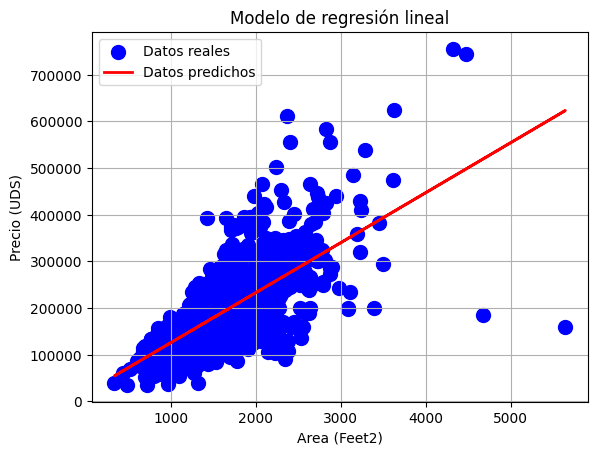

In [ ]:
#Crear visualizacion

plt.scatter(x,y, color = "b", s=100, label = "Datos reales")
plt.plot(x, Y_predic, color = "r", linewidth = 2, label = "Datos predichos")


plt.xlabel("Area (Feet2)")
plt.ylabel("Precio (UDS)")
plt.title("Modelo de regresión lineal")
plt.legend()
plt.grid()
plt.show()





##Regresion lineal multiple

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import seaborn as sns


In [ ]:
data = sns.load_dataset("diamonds")
data

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [ ]:
data.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [ ]:
data.shape

(53940, 10)

In [ ]:
print(data.isnull().sum())

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


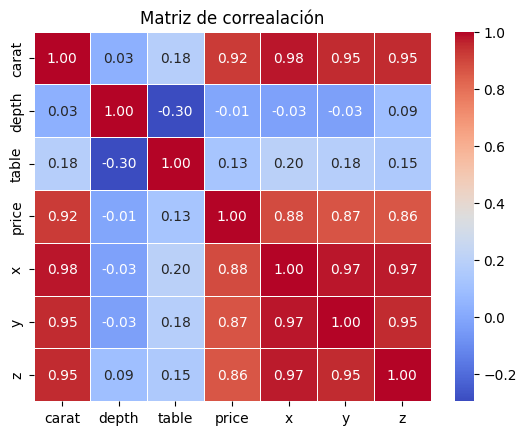

In [ ]:
# Matriz de correlacion

corr_matriz = data.corr(numeric_only=True)

sns.heatmap(corr_matriz, annot= True, cmap = "coolwarm", fmt=".2f", linewidths= 0.5)
plt.title("Matriz de correalación")
plt.show()


In [ ]:
x = data[["carat", "table"]]
y = data["price"]

# 70% entrenamiento
# 30% prueba

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.3, random_state= 42)



In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)
y_predict = model.predict(x_test)
r2 = r2_score(y_test, y_predict)
rms = mean_squared_error(y_test, y_predict)**(1/2)

In [ ]:
print("Coeficientes del modelo : ", model.coef_)
print("Intercepto : ", model.intercept_)
print(f"r2 del modelo :  {r2:.2f}")
print(f"Error cuadratico medio : {rms:.2f}")

Coeficientes del modelo :  [7828.41047886  -76.05399153]
Intercepto :  2060.770743616068
r2 del modelo :  0.85
Error cuadratico medio : 1528.36


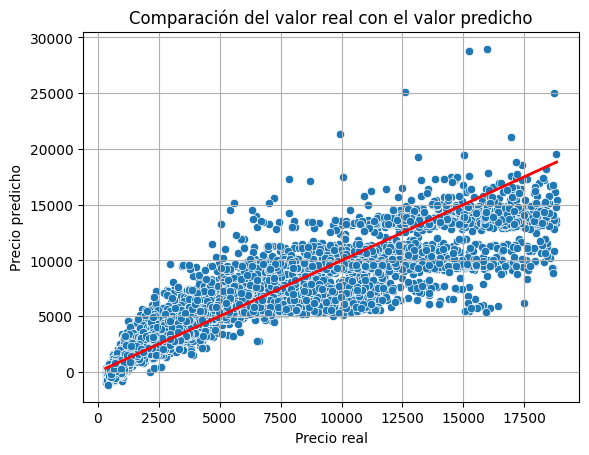

In [ ]:
sns.scatterplot(x = y_test, y = y_predict)
lim = [y_test.min(), y_test.max()]
plt.plot(lim, lim, color = "red", linewidth = 2 )
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Comparación del valor real con el valor predicho")
plt.grid()
plt.show()

